Validatation prep step

In [1]:
import random, shutil
from pathlib import Path

random.seed(12)
SRC = Path("data")
DST = Path("pyannote")
VAL_FRAC = 0.15

dev_uris = sorted(w.stem for w in (SRC/"audio/dev").glob("*.wav"))
random.shuffle(dev_uris)

n_val = int(VAL_FRAC * len(dev_uris))
splits = {
    "train": (sorted(dev_uris[n_val:]), "dev"),
    "val":   (sorted(dev_uris[:n_val]), "dev"),
    "test":  (sorted(w.stem for w in (SRC/"audio/test").glob("*.wav")), "test"),
}

for split, (uris, src_split) in splits.items():
    audio_dir = DST/split/"audio"
    audio_dir.mkdir(parents=True, exist_ok=True)
    
    r_dir = DST/split/"annotations"
    r_dir.mkdir(parents=True, exist_ok=True)
    
    for uri in uris:
        shutil.copy2(SRC/f"audio/{src_split}/{uri}.wav", audio_dir/f"{uri}.wav")
        shutil.copy2(SRC/f"annotations/{src_split}/{uri}.rttm", r_dir/f"{uri}.rttm")

UEM prep step

In [1]:
import librosa
from pathlib import Path

base = Path("data/pyannote")
for split in ["train", "val", "test"]:
    wav_dir = base/split/"audio"
    uem = open(base/split/f"{split}.uem", "w")
    lst = open(base/split/f"{split}.lst", "w")
    
    for wav in sorted(wav_dir.glob("*.wav")):
        dur = librosa.get_duration(path=str(wav))
        uem.write(f"{wav.stem} 1 0.000 {dur:.3f}\n")
        lst.write(f"{wav.stem}\n")
        
    uem.close()
    lst.close()

In [16]:
from pyannote.database import registry, FileFinder

registry.load_database("data/pyannote/database.yml")
protocol = registry.get_protocol(
    "VoxConverse.SpeakerDiarization.main",
    preprocessors={"audio": FileFinder()},
)
test_file = next(protocol.test())


/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/database/registry.py:499: UserWarning: Replacing existing VoxConverse.SpeakerDiarization.main protocol by the one defined in '/Users/neprog/Desktop/kse/audio_dl/kse-deep-audio-lab2/data/pyannote/database.yml'.
  warnings.warn(


In [3]:
from pyannote.audio import Model
import os

model = Model.from_pretrained("pyannote/segmentation-3.0", use_auth_token=os.environ["HF_TOKEN"])

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

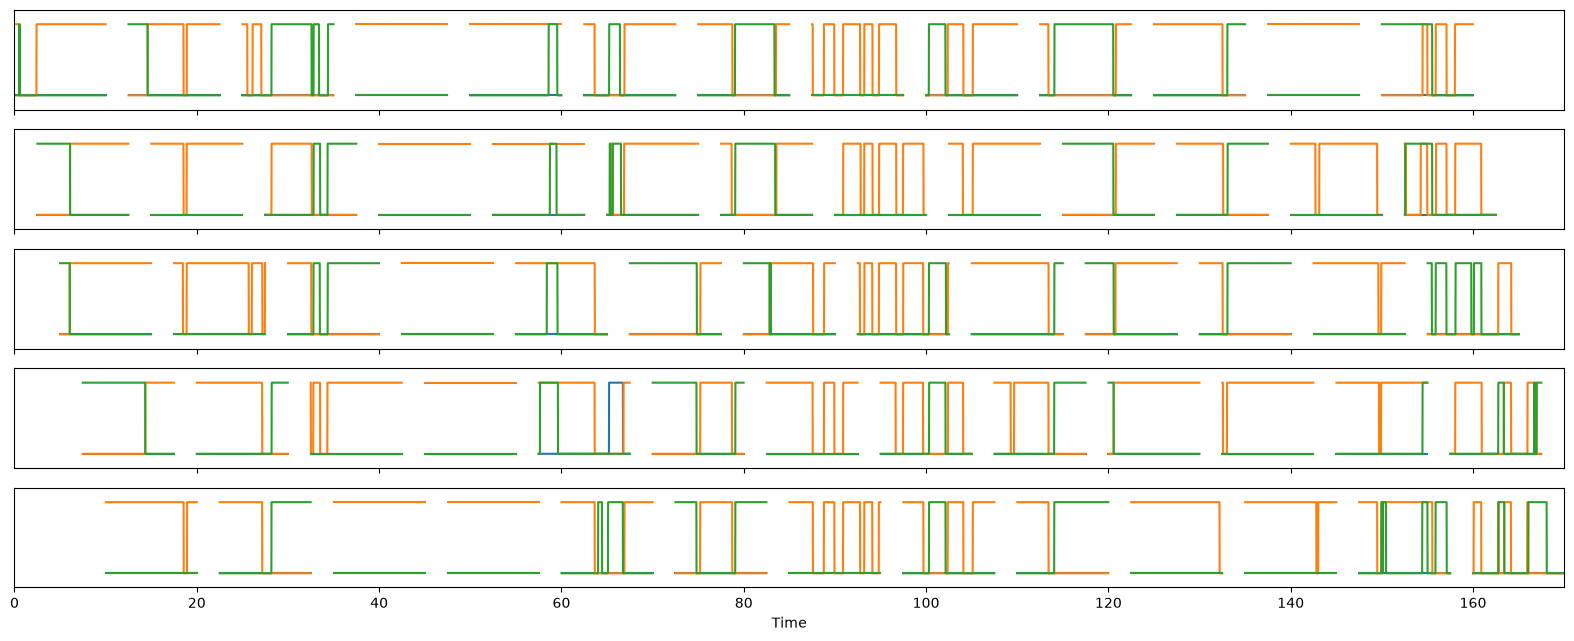

In [17]:
from pyannote.audio import Inference

spk_probability = Inference(model, step=2.5)(test_file)
spk_probability

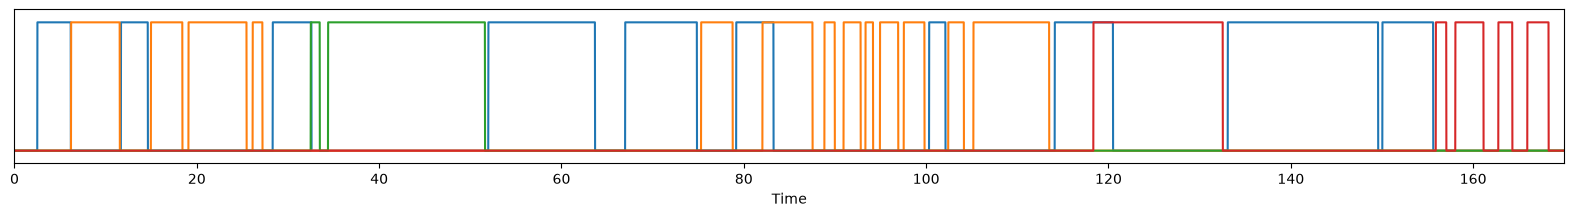

In [18]:
from pyannote.core import notebook

test_file["annotation"].discretize(notebook.crop, resolution=0.010)

In [19]:
from pyannote.audio.tasks import SpeakerDiarization

seg_task = SpeakerDiarization(protocol, duration=10.0, max_speakers_per_chunk=3, max_speakers_per_frame=2)

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/audio/core/task.py:298: UserWarning: num_workers > 0 is not supported with macOS and Python 3.8+: setting num_workers = 0.
  warnings.warn(


In [ ]:
from pyannote.audio.utils.signal import binarize
from pyannote.audio.utils.metric import DiscreteDiarizationErrorRate
import torch

def test(model, protocol, subset="test"):
    metric = DiscreteDiarizationErrorRate()
    files = list(getattr(protocol, subset)())

    device = torch.device("mps")
    inference = Inference(model, device=device)

    for file in files:
        reference = file["annotation"]
        hypothesis = binarize(inference(file))
        uem = file["annotated"]
        _ = metric(reference, hypothesis, uem=uem)

    return abs(metric)

In [28]:
der_pretrained = test(model=model, protocol=protocol, subset="test")
print(f"Local DER (pretrained) = {der_pretrained * 100:.1f}%")

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/audio/utils/metric.py:233: RuntimeWarning: overflow encountered in scalar add
  components[name] += window_components[name]
/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/database/protocol/protocol.py:140: UserWarning: Existing precomputed key "annotation" has been modified by a preprocessor.
  warnings.warn(msg.format(key=key))
/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/audio/utils/metric.py:83: RuntimeWarning: invalid value encountered in scalar divide
  der = (false_alarm + missed_detection + confusion) / total
/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/audio/utils/metric.py:239: RuntimeWarning: overflow encountered in scalar add
  components["false alarm"]
/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/audio/utils/metric.py:238: RuntimeWarning: invalid value encountered in scalar divid

Local DER (pretrained) = nan%


Claude's response 
```
Inside DiscreteDiarizationErrorRate, the code counts frames in 16-bit floats (np.half). A
16-bit float maxes out at 65504. Your evaluation has way more frames than that — and remember
those 5× overlapping windows we found earlier? Each frame gets counted ~5 times, so the running
total blows past 65504, overflows to infinity, and something / inf = nan.
```

In [ ]:
import numpy as np
import pyannote.audio.utils.metric as M
from pyannote.audio.utils.permutation import permutate

def _ddes_safe(reference, hypothesis):
    reference  = reference.astype(np.float32)      
    hypothesis = hypothesis.astype(np.float32)
    (hypothesis,), _ = permutate(reference[np.newaxis], hypothesis)

    total = float(np.sum(reference))
    detection_error  = np.sum(hypothesis, axis=1) - np.sum(reference, axis=1)
    false_alarm = np.maximum(0,  detection_error)
    missed_detection = np.maximum(0, -detection_error)
    confusion = np.sum((hypothesis != reference) * hypothesis, axis=1) - false_alarm

    fa, md, cf = float(np.sum(false_alarm)), float(np.sum(missed_detection)), float(np.sum(confusion))
    der = (fa + md + cf) / total if total else float("nan")
    return der, {"false alarm": fa, "missed detection": md, "confusion": cf, "total": total}

M.discrete_diarization_error_rate = _ddes_safe

In [30]:
der_pretrained = test(model=model, protocol=protocol, subset="test")
print(f"Local DER (pretrained) = {der_pretrained * 100:.1f}%")

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/database/protocol/protocol.py:140: UserWarning: Existing precomputed key "annotation" has been modified by a preprocessor.
  warnings.warn(msg.format(key=key))


Local DER (pretrained) = 11.1%


In [32]:
from copy import deepcopy
import lightning.pytorch as pl

finetuned = deepcopy(model)
finetuned.task = seg_task

trainer = pl.Trainer(devices=1, max_epochs=1)
trainer.fit(finetuned)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoi

┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name              ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃       In sizes ┃                  Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ sincnet           │ SincNet          │ 42.6 K │ eval  │ 960 M │ [1, 1, 160000] │               [1, 60, 589] │
│ 1 │ lstm              │ LSTM             │  1.4 M │ eval  │     0 │   [1, 589, 60] │    [[1, 589, 256], [[8, 1, │
│   │                   │                  │        │       │       │                │        128], [8, 1, 128]]] │
│ 2 │ linear            │ ModuleList       │ 49.4 K │ eval  │     0 │              ? │                          ? │
│ 3 │ classifier        │ Linear           │    903 │ train │ 1.1 M │  [1, 589, 128] │                [1, 589, 7] │
│ 4 │ activation        │ LogSoftmax       │      0 │ train │     0 │    [1, 589, 7] │                [1, 589, 7] │
│ 5 │ powerset          │ Powerset         │      0 │ train │     0 │              ? │                          ? │
│ 6 │ validation_metric │ MetricCollection │      0 │ train │     0 │              ? │                          ? │
└───┴───────────────────┴──────────────────┴────────┴───────┴───────┴────────────────┴────────────────────────────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 5.893                                                                      
Modules in train mode: 11                                                                                          
Modules in eval mode: 19                                                                                           
Total FLOPs: 1.0 B

Output()

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connec
tor.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your 
`IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), 
`__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 
20 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this 
is intentional, you can ignore this warning.

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/torch_audiomentations/core/transforms_interface.
py:221: UserWarning: target_rate is required by Identity. It has been automatically inferred from targets shape to 
59. If this is incorrect, you can pass it directly.
  warnings.warn(

`Trainer.fit` stopped: `max_epochs=1` reached.


In [33]:
der_finetuned = test(model=finetuned, protocol=protocol, subset="test")
print(f"Local DER (finetuned) = {der_finetuned * 100:.1f}%")

/Users/neprog/mamba/envs/pyannote-env/lib/python3.11/site-packages/pyannote/database/protocol/protocol.py:140: UserWarning: Existing precomputed key "annotation" has been modified by a preprocessor.
  warnings.warn(msg.format(key=key))


Local DER (finetuned) = 10.8%
